# Simulering av radioaktiv nedbrytning
Av Sigurd Rage - USN

![Terningkast som simulering av radioaktiv nedbrytning](images/terningkast.jpg)

# Introduksjon
I denne aktiviteten ser vi på hvordan vi kan simulere radioaktiv nedbrytning med terninger og programmering. Den tar utgangspunkt i et klassisk forsøk der elevene bruker terninger for å simulere radioaktiv nedbrytning, samler data og analyserer resultatene i CAS-verktøy (Geogebra) og vurderer resultatet mot en matematisk modell. Deretter tas problemet videre i en programmeringsoppgave. Aktiviteten handler både om modellering og sannsynlighet, og hvordan stokastiske forsøk kan avvike fra den beregnede modellen spesielt hvis antall terninger er få.

Aktiviteten passer best for elever på 10. trinn og dekker flere aktuelle kompetansemål fra både 9. og 10. trinn. Den kan også fungere som tverrfaglig oppgave med naturfag

## Kompetansemål
Matematikk 9. trinn
* berekne og vurdere sannsyn i statistikk og spel
* simulere utfall i tilfeldige forsøk og berekne sannsynet for at noko skal inntreffe, ved å bruke programmering

Matematikk 10. trinn
* bruke funksjonar i modellering og argumentere for framgangsmåtar og resultat
* modellere situasjonar knytte til reelle datasett, presentere resultata og argumentere for at modellane er gyldige
* utforske matematiske eigenskapar og samanhengar ved å bruke programmering
* utforske samanhengen mellom konstant prosentvis endring, vekstfaktor og eksponentialfunksjonar
* utforske og samanlikne eigenskapar ved ulike funksjonar ved å bruke digitale verktøy

Naturfag 10. trinn
* bruke programmering til å utforske naturfaglige fenomener
* bruke og lage modeller for å forutsi eller beskrive naturfaglige prosesser og systemer og gjøre rede for modellenes styrker og begrensninger

## Forkunnskaper
* Kjennskap til bruk av variabler og operasjoner, sløyfer og betingelser i Python
* Kjennskap til sannsynlighet og sannsynlighetsmodeller

# Analog aktivitet

## Aktivitet med terninger
Elevene deles i grupper og får utdelt et terningssett hver. Dess flere terninger dess bedre, vi hadde 165 terninger i vår gjennomføring. Elevene kaster terningene i runder og fjerner alle terningene som viser 6, og noterer hvor mange terninger de har igjen etter hver runde. Etter 10 runder oppsummeres gruppenes resultater i plenum og vi regner ut totalen for hver runde

## Arbeid med teoretisk modell
Elevene jobber seg fram til en modell for forsøket. Siden sannsynligheten for å få en sekser på terningen er $ P = \frac{1}{6} $ vil de kunne resonnere seg frem til at sannsynligvis kan vi forvente at $ \frac{1}{6} $ av terningene fjernes for hver runde. Dersom de ikke har lært om eksponentialfunksjoner og renters rente enda, er det likevel mulig å lage en tabell over forventningsverdiene for hver runde i forsøket. Dersom vi bruker eksponentialfunksjoner så kan da en mulig modell for forsøket være eksponentialfunksjonen
$$ M(x) = M_0 \cdot (1-\frac{1}{6})^x  = M_0 \cdot \frac{5}{6}^x$$
der $ M_0 $ er mengden terninger ved start.

## Oppsummering og analyse

![Oppsummering på tavle](images/oppsummering.jpg)

Resultatene legges inn i graftegner og kan analyseres visuelt

![Plott av resultater](images/resultatplott.png)

I neste plott har vi brukt regresjon (RegEksp) og fått en regresjonskurve med funksjonen $ M = 215.7 \cdot 0.74^x $ i grønt.
I tillegg har vi lagt inn den teoretiske sannsynlighetsmodellen $ M = 165 \cdot \frac{5}{6}^x $

![regresjon og teoretisk modell](images/regresjon-modell.png)

Her ser vi at regresjonsfunksjonen ikke likner på den teoretiske modellen, ei heller passer dataene særlig bra inn, så hva har skjedd?

Dette er en fin anledning til at elevene får diskutere.

# Programmering: Utvikle koden steg for steg

I dette avsnittet skal vi se på hvordan vi kan utvikle et program som simulerer radioaktiv nedbrytning med utgangspunkt i forsøket med terninger. I denne prosessen skriver vi ikke programmet ut fra topp til bunn, men lager det steg for steg og går kun videre når vi er fornøyd med at koden fungerer som tenkt.

## Forslag til fremgangsmåte
1. få koden til å kaste en terning (ikke med i vårt eksempel)
2. få koden til å kaste et knippe med terninger (feks 10 terninger) <-- her starter vi!
3. få koden til å kaste et knippe med terninger, fjerne seksere, og kaste resten av terningen i flere omganger
4. få koden til å lage en liste (tabell) over restmengden av terninger
5. få koden til å visualisere resultatet

## Pseudokode
Etter at den analoge aktiviteten er gjennomført kunne det være en fin øvelse for elevene å lage en pseudokode for fremgangsmåten. Pseudokode er en presis språklig beskrivelse av hva programmet skal utføre og er et godt utgangspunkt når vi skal programmerere en løsning

```{hint} Forslag til pseudokode
:class: dropdown

1. kaste 165 terninger (FOR)
2. fjerne alle seksere (IF)
3. Gjenta pkt 1 og 2 ti ganger (FOR)
4. spare på restmengden etter hver runde i en tabell
5. lage en grafisk presentasjon av resultatet

```

## Å gjøre ett forsøk med å kaste et knippe terninger og telle 6-ere

Vi begynner med å kaste et knippe terninger og se om vi kan finne ut hvor mange 6-ere som skal fjernes fra mengden, og regne ut ny restmengde for ett forsøk

```{code-block} Python
# for å få python til å lage tilfeldige tall trenger vi dette biblioteket:
import random as rnd

# antall (mengde) terninger, begynner med et lavt tall her for å lettere
# kunne sjekke om koden er riktig:
M = 10


for i in range(M):
    terningkast = rnd.randint(1,6)
    print(terningkast)
    
    if terningkast == 6:
        M = M - 1

print("\nEtter å ha fjernet alle 6-erne har vi " +str(M) + " terninger igjen")
```

```{tip} Oppgaver
1. Les igjennom koden sammen med sidepartner og diskuter hvordan dere tror koden fungerer
2. Kopier koden til ditt python-program (Spyder, Thonny, trinket.io (NB krever Pyton 3), kjør koden flere ganger og sjekk at det kastes 10 terninger, og at restantallet "rest" stemmer.
3. Når vi bare kaster 10 terninger i slengen hender det ganske ofte at vi ikke får en 6-er i det hele tatt. Øk mengden terninger til feks 20, 50 og 100 og kjør koden på nytt.
4. Hvis du har fått til oppgave 2, så er det kanskje ikke nødvendig å skrive ut alle terningkastene, det tar mye plass og vi er ganske sikre på at koden fungerer. Kan du fjerne, eller kommentere ut den linja som skriver ut alle terningkastene?
```

````{hint} Løsning oppgave 1
:class: dropdown
```{code-block} Python
# Kaster et knippe terninger!

# for å få python til å lage tilfeldige tall trenger vi dette biblioteket:
import random as rnd

# antall (mengde) terninger, begynner med et lavt tall her for å lettere
# kunne sjekke om koden er riktig:
M = 10

# Vi bruker en for-sløyfe for å kaste resterende terninger:
for i in range(M):
    # funksjonen rnd.randint(1,6) gir oss ett heltall mellom 1 og 6
    # akkurat som en terning
    terningkast = rnd.randint(1,6)

    # skriver ut alle terningkastene slik at vi kan sjekke at
    # koden fungerer riktig
    print(terningkast)

    # Hvis terningkastet er en 6-er, så skal den fjernes fra
    # mengden slik at vi får en ny rest
    if terningkast == 6:
        M = M - 1 # trekker en fra mengden
    
# skriver ut restverdien til konsoll, så kan vi kontrollere at 
# koden fungerer som den skal
print("\nEtter å ha fjernet alle 6-erne har vi " +str(M) + " terninger igjen")
```
````

## Å gjenta forsøket flere ganger og holde rede på restmengden
I forrige aktivitet kastet vi bare terninger for ett forsøk, eller én runde om du vil. For å kunne gjenta forsøket må vi bruke nøstede sløyfer. Vi kaller antall forsøk N, og fortsetter å kalle mengde terninger M:

```{code-block} Python
import random as rnd

M = 10
N = 10


print("Restmengde før vi begynner (runde 0) " + str(M) )

for j in range(N):

    for i in range(M):
        terningkast = rnd.randint(1,6)
        if terningkast == 6:
            M = M - 1

    print("Restmengde etter " + str(j+1) + " runder: " + str(M))
```

```{tip} Oppgaver
1. Les koden sammen med sidepartner og forklar hverandre hvordan denne koden kjører. Hvor i denne koden finner dere koden vi lagde i forrige steg?
2. Hva betyr det å "nøste" sløyfer i programmering, og hvilken hensikt har det her?
3. Kopier koden til ditt python-program og kjør den flere ganger. Hva ser dere?
4. Endre antall forsøk N til en høyere verdi, feks 20, 50 eller mer. Hva ser dere? Øk deretter antallet terninger M til en høyere verdi. Hva ser dere?
```

````{hint} Løsning på oppgave 1
:class: dropdown
```{code-block} Python
# Kaster et knippe terninger, men denne gangen gjentar vi prosessen flere ganger

# for å få python til å lage tilfeldige tall trenger vi dette biblioteket:
import random as rnd

# antall (mengde) terninger, begynner med et lavt tall her for å lettere
# kunne sjekke om koden er riktig:
M = 10

# antall forsøk (runder) i eksperimentet
N = 10

# skriver ut mengden før vi starter å fjerne terninger:
print("Restmengde før vi begynner (runde 0) " + str(M) )

# Vi bruker en for-sløyfe for å gjenta forsøket N ganger:
for j in range(N):

    # Vi bruker en for-sløyfe for å kaste M terninger:
    for i in range(M):
        # funksjonen rnd.randint(1,6) gir oss ett heltall
        # mellom 1 og 6 akkurat som en terning
        terningkast = rnd.randint(1,6)

        # denne gangen er vi ikke interesserte i å skrive ut
        # hvert eneste terningkast. Her er koden kommentert ut,
        # men kan gjerne slettes!
        # print(terningkast)

        # Hvis terningkastet er en 6-er, så skal den fjernes fra
        # mengden slik at vi får en ny rest
        if terningkast == 6:
            M = M - 1 # trekker en fra mengden

    # Nå er vi mer interessert i å se restmengden etter hvert
    # forsøk, så lager en utskrift for dette etter hvert forsøk
    print("Restmengde etter " + str(j+1) + " runder: " + str(M))
```
````

## Oppsummering så langt

Nedenfor er koden vi har laget til nå. Denne gangen er det også resultater fra en kjøring som tilsvarer det analoge eksperimentet som beskrevet først på denne aktiviteten. I min gjennomføring var det M = 165 terninger, og vi gjentok forsøket N = 10 ganger. De fleste av kommentarene er fjernet slik at koden ser kortere og enklere ut!

In [1]:
import random as rnd
# Antall terninger i hvert forsøk
M = 165
# antall forsøk (runder) i eksperimentet
N = 10

print("Restmengde før vi begynner (runde 0) " + str(M) )

for j in range(N):
    
    for i in range(M):
        terningkast = rnd.randint(1,6)
        if terningkast == 6:
            M = M - 1 # trekker en fra mengden rest

    print("Restmengde etter " + str(j+1) + " runder: " + str(M))

Restmengde før vi begynner (runde 0) 165
Restmengde etter 1 runder: 128
Restmengde etter 2 runder: 108
Restmengde etter 3 runder: 85
Restmengde etter 4 runder: 69
Restmengde etter 5 runder: 58
Restmengde etter 6 runder: 45
Restmengde etter 7 runder: 40
Restmengde etter 8 runder: 37
Restmengde etter 9 runder: 30
Restmengde etter 10 runder: 27


```{tip} Oppgaver
1. Kan du og sidepartner fortsatt lese koden og forstå hvordan den kjører uten kommentarer?
2. Kopier koden til ditt python-program og kjør koden. Sammenlign resultatene fra koden med resultatene fra den analoge gjennomføringen over, eller din egen kode. Hvis dere har gjort det analoge forsøket, endre antall terninger M til det antallet terninger dere brukte i gjennomføringen. Bruk gjerne graftegner (Geogebra) til å visualisere resultatene.
```

## Lage en liste for hvor mange terninger vi har igjen
Frem til nå har vi brukt utskrift til skjerm (print) for å undersøke resultatene av kjøring av koden. Nå som vi er rimelig sikre på at koden kjører som vi ønsker kan vi begynne å planlegge videre. Det kunne vært artig å kunne visualisere resultatet grafisk for eksempel. Første steget på veien dit er å lage en tabell hvor vi lagrer resultatene av forsøkene. Da trenger vi ikke lenger å skrive ut resultatene med print() som vi gjorde ovenfor

```{code-block} Python
import random as rnd

M = 165
N = 10

# NY kode her
tabell = []
tabell.append(M)

for j in range(N):
    for i in range(M):
        terningkast = rnd.randint(1,6)
        if terningkast == 6:
            M = M - 1 # trekker en fra mengden
            
    # NY kode her
    tabell.append(M)    

print("Tabell over restmengder for hvert forsøk:")
print(tabell)
```

```{tip} Oppgaver
1. Les gjennom koden sammen med sidepartner og diskuter endringene. Hva er fjernet og hvorfor? Hva gjør den nye koden?
2. Kjør koden og se om den gjorde det som dere trodde
```

````{hint} Løsning på oppgave 1
:class: dropdown
```{code-block} Python
# for å få python til å lage tilfeldige tall trenger vi dette biblioteket:
import random as rnd

# antall (mengde) terninger, begynner med et lavt tall her for å lettere
# kunne sjekke om koden er riktig:
M = 165

# antall forsøk (runder) i eksperimentet
N = 10

# NY: tabell for å huske restmengdene
tabell = []
tabell.append(M) #legger til startmengden før vi begynner å kaste.

# Vi trenger ikke skrive ut restmengden til skjermen
# nå som vi bruker en tabell til å huske resultatene!
# print("Restmengde før vi begynner (runde 0) " + str(M) )

# Vi bruker en for-sløyfe for å gjenta forsøket N ganger:
for j in range(N):

    # Vi bruker en for-sløyfe for å kaste M terninger:
    for i in range(M):
        # funksjonen rnd.randint(1,6) gir oss ett heltall
        # mellom 1 og 6 akkurat som en terning
        terningkast = rnd.randint(1,6)

        # denne gangen er vi ikke interesserte i å skrive ut
        # hvert eneste terningkast. Her er koden kommentert ut,
        # men kan gjerne slettes!
        # print(terningkast)

        # Hvis terningkastet er en 6-er, så skal den fjernes fra
        # mengden slik at vi får en ny rest
        if terningkast == 6:
            M = M - 1 # trekker en fra mengden

    # Etter at alle terningene i runden er kastet,
    # legger vi den nye restmengden til tabellen.
    tabell.append(M)    

    # Som nevnt over, trenger vi ikke skrive ut til skjerm her.
    # print("Restmengde etter " + str(j+1) + " runder: " + str(M))

# Skriver ut innholdet av tabellen
print("Tabell over restmengder for hvert forsøk:")
print(tabell)
```
````

## Et enkelt plott av resultatet
Det er enkelt å lage grafiske fremstillinger i Python og det finnes mange ferdige biblioteker som har løsninger til dette. Ett av de mest vanlige er et bibliotek som heter "Matplotlib". I koden nedenfor er det lagt inn et par nye kodelinjer:

```{code-block} Python
import random as rnd

# NY: for å lage en grafisk fremstilling av tabellen trenger vi dette biblioteket
import matplotlib.pyplot as plt

M = 165
N = 10

tabell = []
tabell.append(M)

for j in range(N):
    for i in range(M):
        terningkast = rnd.randint(1,6)
        if terningkast == 6:
            M = M - 1 # trekker en fra mengden
            
    tabell.append(M)    

print("Tabell over restmengder for hvert forsøk:")
print(tabell)

# NY: Disse to linjene er alt som trengs for å skrive ut resultatet i en
# grafisk fremstilling (et plott!)
plt.plot(tabell, "ro") # her betyr "ro" at jeg vil plotte med røde prikker
plt.show()
```

```{tip} Oppgaver
1. Kjør programmet og se hva som skjer!
2. Øk mengden terninger M gradvis. Hva legger dere merke til?
```

## Sammenligne resultatet av terningkastforsøket med den teoretiske modellen
I forrige aktivitet lagde vi et veldig enkelt plott av resultatet av forsøket vårt, og undersøkte hva som skjedde når vi økte antall terninger M. I denne aktiviteten skal vi se på hvordan vi også kan plotte inn den teoretiske funksjonen for resultatet, $ M(x) = M_0 \cdot = M_0 \cdot \frac{5}{6}^x$. For å gjøre dette skal vi bruke en annen type tabeller som heter Arrays. Disse finner vi i et bibliotek som heter "Numpy" som er laget spesielt med tanke på numeriske metoder og som er lette å gjøre matematiske operasjoner på. Dette biblioteket er nærmere beskrevet i aktiviten "Funksjoner og plotting i Python", i denne aktiviteten holder det at vi legger koden inn i programmet vårt. Dere har allerede utviklet selve simuleringen av forsøket som er hovedpoenget med aktiviteten. I programmet under er det lagt inn koder for å lage arrayet og for plotting av grafen. Vi skal ikke gå nøyere inn på forklaring av denne koden, men den virker! I tillegg er det resultat av en kjøring!

Tabell over restmengder for hvert forsøk:
[165, 133, 105, 87, 69, 61, 53, 43, 38, 32, 21]


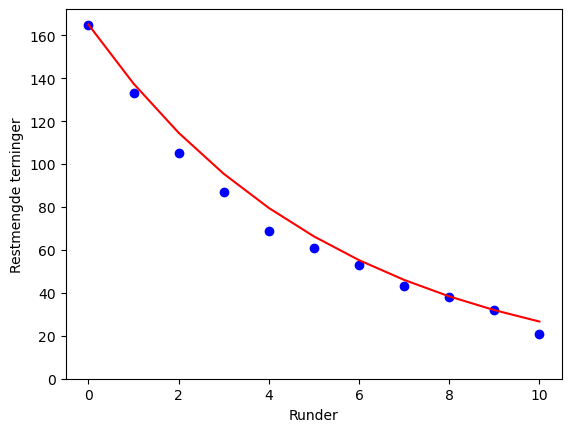

In [1]:
import random as rnd

# for å lage en grafisk fremstilling av tabellen trenger vi dette biblioteket
import matplotlib.pyplot as plt

# NY: importerer biblioteket numpy for å lage Arrays
import numpy as np

# antall (mengde) terninger, begynner med et lavt tall her for å lettere
# kunne sjekke om koden er riktig:
M = 165

# antall forsøk (runder) i eksperimentet
N = 10

# tabell for å huske restmengdene
tabell = []
tabell.append(M) #legger til startmengden før vi begynner å kaste.

# Vi bruker en for-sløyfe for å gjenta forsøket N ganger:
for j in range(N):

    # Vi bruker en for-sløyfe for å kaste M terninger:
    for i in range(M):
        # funksjonen rnd.randint(1,6) gir oss ett heltall
        # mellom 1 og 6 akkurat som en terning
        terningkast = rnd.randint(1,6)


        # Hvis terningkastet er en 6-er, så skal den fjernes fra
        # mengden slik at vi får en ny rest
        if terningkast == 6:
            M = M - 1 # trekker en fra mengden

    # Etter at alle terningene i runden er kastet,
    # legger vi den nye restmengden til tabellen.
    tabell.append(M)    

# Skriver ut innholdet av tabellen
print("Tabell over restmengder for hvert forsøk:")
print(tabell)

# NY: lager X og Y-tabeller for plotting med numpy
x = np.linspace(0, len(tabell)-1, len(tabell))
y = np.array(tabell) # henter y-verdiene fra tabellen
fasit_y = y[0]*(5/6)**x

# NY: plotter resultatet og modellen i samme plot
# og setter y-aksen slik at den alltid viser 0
f, ax = plt.subplots(1)
ax.plot(x, y, "bo")
ax.plot(x, fasit_y, "r")
ax.set_ylim(ymin=0)
plt.xlabel("Runder")
plt.ylabel("Restmengde terninger")
plt.show(f)

```{tip} Oppgaver
1. Hvor i koden ligger modellen $ M(x) = M_0 \cdot \frac{5}{6}^x$ ?
2. Hvorfor må jeg hente starverdien fra y[0]
3. Kjør koden flere ganger og se hva som skjer med det simulerte resultatet fra terningkastene i forhold til den teoretiske modellen?
4. Øk mengden terninger M gradvis, til f.eks 500, 1000, 10000 og kjør koden flere ganger for hver endring. Hva observerer dere? Hvorfor ser det ut til at forsøket nærmer deg den teoretiske modellen?
5. Øk mengden kast (repetisjoner) N til 20, 50, 100 og kjør koden flere ganger, gjerne også med forskjellig verdi for M. Hva skjer nå?
```

## Todo
Her kommer følgende steg videre
- Drøfte kontinuitet i modellen og diskontinuitet (diskrete verdier) i simulert datasett
- Eventuelt også gi mulighet for å lagre forsøket til excel-fil
- Som aktiviteten fremstår nå, så er den delvis lærerveiledning og delvis elevaktivitet. Dokumentent bør skrives om slik at det leses enhetlig som en av delene?


Her skal det komme en mer steg-for-steg progresjon for elevene (delvis basert på PRIMM). Nedenfor er forslag til ferdig kode som har samme startparametere som det analoge forsøket med terninger. Ved å kjøre flere ganger vil man legge merke til at simulasjonen ligger nærmere teoretisk modell dess flere "terninger" som er igjen i mengden (altså i starten av forsøket). Når restmengden blir lavere så varierer resulatet mer. Dette kan kobles til store talls lov. Vi arbeider tross alt med et stokastisk forsøk i denne simuleringen, og da vil variasjon i utfall få mer å si.

Når dette er belyst kan man heller leke seg litt med programmet, og øke mengden (165 terninger skal simulere et gram uran som inneholder $2.53 \cdot 10^{21} $ antall kjerner?). Man kan også leke litt med å øke antall iterasjoner (runder).